# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

fatal: destination path 'MNIST' already exists and is not an empty directory.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [6]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

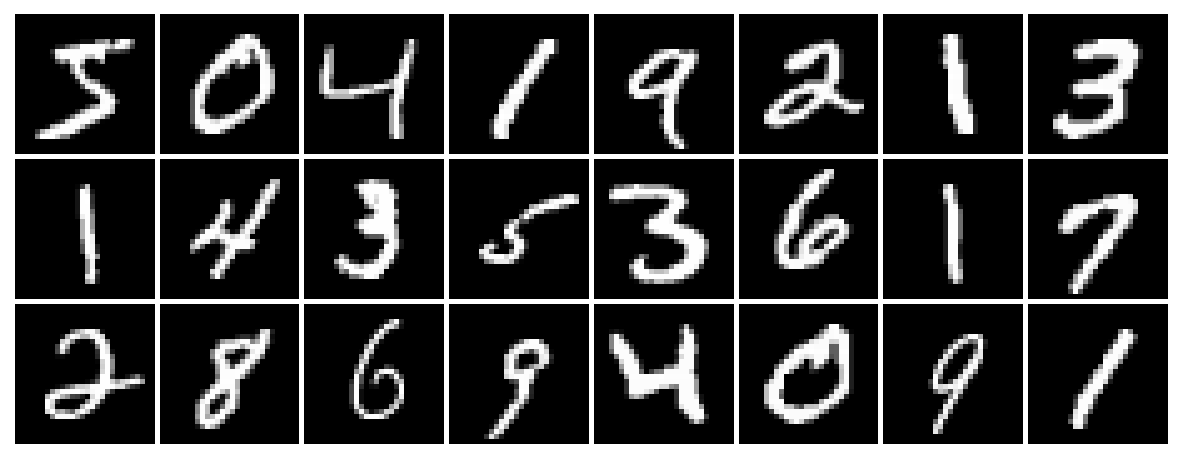

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


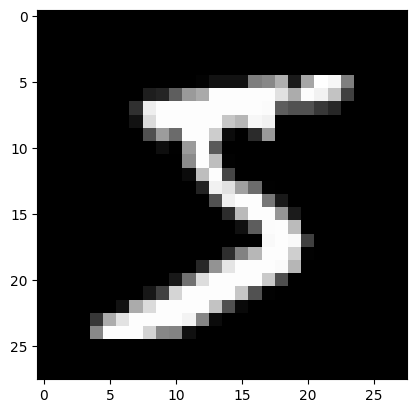

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.1557,  0.3237,  0.1351,  0.3270, -0.0313, -0.0371,  0.1507, -0.2152,
          0.1039, -0.1313],
        [-0.3107,  0.1979, -0.1788, -0.0307,  0.1152, -0.1041, -0.0961,  0.0665,
         -0.1370,  0.0791],
        [ 0.0437, -0.1033,  0.1361,  0.2009, -0.1368,  0.1248,  0.0756, -0.0332,
          0.1211, -0.2121],
        [ 0.0267,  0.0415,  0.0595,  0.1603, -0.1865, -0.1718, -0.0601, -0.1154,
          0.0242,  0.0122],
        [-0.3517, -0.0427, -0.0965,  0.0538,  0.0058,  0.0404,  0.1109, -0.2449,
         -0.2557,  0.0100]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [12]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [13]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2639, Train Acc: 0.9410, Val Loss: 0.3900, Val Acc: 0.8950
Epoch [2/100], Train Loss: 0.2626, Train Acc: 0.9420, Val Loss: 0.3891, Val Acc: 0.8950
Epoch [3/100], Train Loss: 0.2613, Train Acc: 0.9420, Val Loss: 0.3882, Val Acc: 0.8950
Epoch [4/100], Train Loss: 0.2600, Train Acc: 0.9420, Val Loss: 0.3873, Val Acc: 0.8950
Epoch [5/100], Train Loss: 0.2587, Train Acc: 0.9420, Val Loss: 0.3864, Val Acc: 0.8950
Epoch [6/100], Train Loss: 0.2574, Train Acc: 0.9420, Val Loss: 0.3855, Val Acc: 0.8950
Epoch [7/100], Train Loss: 0.2562, Train Acc: 0.9430, Val Loss: 0.3846, Val Acc: 0.8950
Epoch [8/100], Train Loss: 0.2550, Train Acc: 0.9430, Val Loss: 0.3838, Val Acc: 0.8950
Epoch [9/100], Train Loss: 0.2538, Train Acc: 0.9430, Val Loss: 0.3829, Val Acc: 0.8950
Epoch [10/100], Train Loss: 0.2526, Train Acc: 0.9430, Val Loss: 0.3821, Val Acc: 0.9000
Epoch [11/100], Train Loss: 0.2514, Train Acc: 0.9440, Val Loss: 0.3813, Val Acc: 0.9050
Epoch [12/100], Train Loss: 0.

In [14]:
print('Final loss:', loss.item())

Final loss: 0.2652049660682678


### Visualizando gráfico de perda durante o treinamento

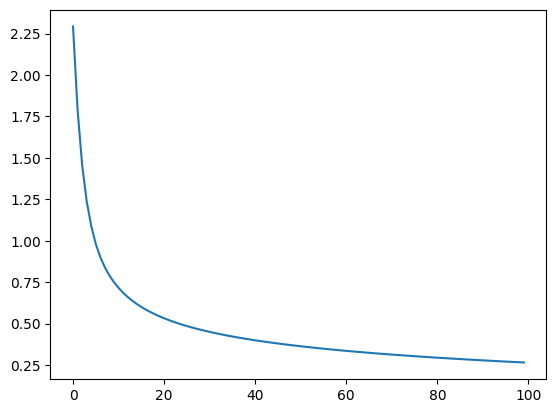

In [15]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

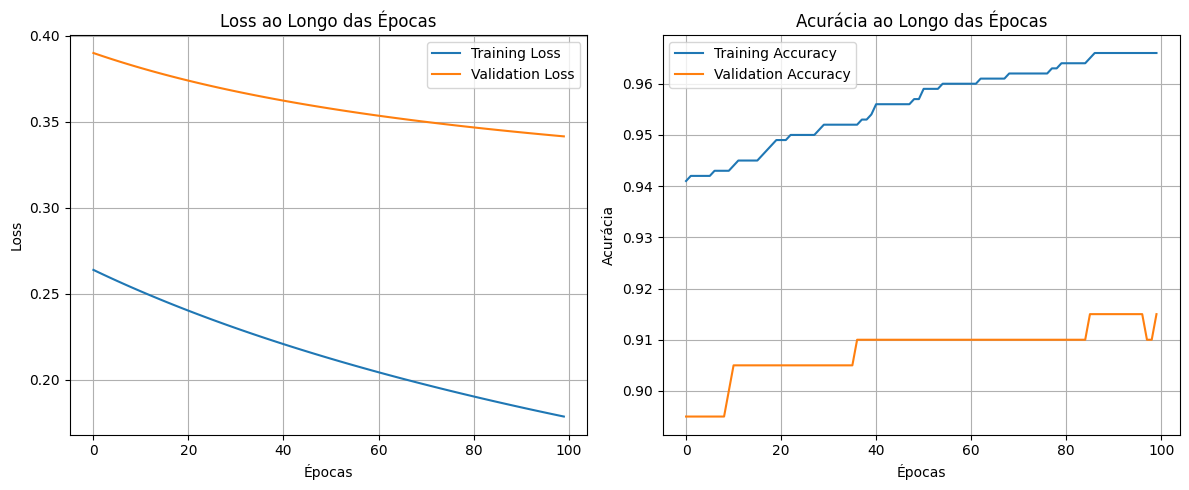

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [17]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.966


### Matriz de confusão com dados de treinamento e teste

In [18]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,103,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


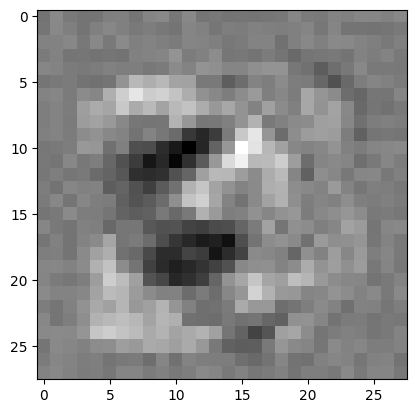

In [19]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

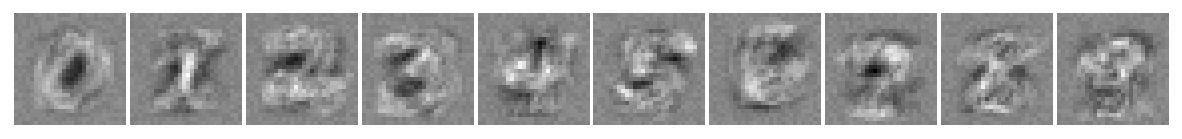

In [20]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

In [21]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

In [22]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.0959,  0.2321, -0.3199,  0.2862,  0.1169,  0.5686,  0.0567,  0.2877,
          0.1368, -0.4568],
        [ 0.1213,  0.2454, -0.2421,  0.0489,  0.1481,  0.3156,  0.3142, -0.0355,
          0.3694, -0.2591],
        [-0.2822,  0.2908, -0.2496,  0.2075,  0.1175,  0.1495, -0.1242, -0.1225,
         -0.0534, -0.3538],
        [-0.0238, -0.0347, -0.3281,  0.1853,  0.1433,  0.1771,  0.0886, -0.2642,
          0.0744, -0.2094],
        [ 0.0391,  0.4630, -0.0457,  0.1110,  0.1653,  0.2139, -0.0047, -0.1246,
         -0.2343, -0.2694]], grad_fn=<AddmmBackward0>)

In [23]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

In [24]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    grad_4 = model.state_dict()['weight'][4, :]
    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], \n' \
          f'Train Loss: {loss_train.item():.4f}, \n' \
          f'Train Acc: {accuracy_train:.4f}, \n' \
          f'Val Loss: {loss_val.item():.4f}, \n' \
          f'Val Acc: {accuracy_val:.4f}\n' \
          f'Grad 4: {grad_4[0:100]}\n')

Epoch [1/100], 
Train Loss: 2.3500, 
Train Acc: 0.0560, 
Val Loss: 1.9236, 
Val Acc: 0.5200
Grad 4: tensor([-0.0202, -0.0260, -0.0148, -0.0005, -0.0168,  0.0174, -0.0163,  0.0097,
        -0.0110, -0.0298,  0.0218, -0.0064, -0.0145,  0.0127, -0.0103, -0.0243,
         0.0041, -0.0189, -0.0068,  0.0121,  0.0139,  0.0112, -0.0258, -0.0275,
        -0.0046, -0.0267, -0.0341,  0.0277,  0.0096, -0.0042, -0.0202, -0.0084,
        -0.0114, -0.0068, -0.0230,  0.0084, -0.0100, -0.0181, -0.0337, -0.0307,
         0.0265, -0.0253,  0.0005, -0.0128,  0.0300, -0.0296, -0.0231, -0.0298,
         0.0137,  0.0089, -0.0258, -0.0007,  0.0118, -0.0084,  0.0200, -0.0238,
         0.0219,  0.0003, -0.0256,  0.0285, -0.0075, -0.0283, -0.0349,  0.0120,
         0.0186, -0.0102,  0.0218,  0.0146, -0.0321,  0.0296, -0.0147, -0.0104,
         0.0307,  0.0301,  0.0148,  0.0158,  0.0251,  0.0069,  0.0179,  0.0153,
         0.0057, -0.0349, -0.0194, -0.0118, -0.0252, -0.0337,  0.0107, -0.0229,
        -0.0355, -0.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

1. Qual é o shape da matriz de entrada na rede?

As imagens de entrada possuem 28*28 pixels (784 pixels) de forma que a matriz de entrada na rede é um vetor de uma coluna com 784 linhas representando o valor de cada pixel da imagem

2. Qual é o shape da saída da rede?

A matriz de saída corresponde a probabilidades entre 10 classes possíveis para a classificação do número, 0 a 9. Dessa forma o shape de saída é um vetor de uma única coluna com 10 linhas contendo as probabilidades de cada classe

3. Qual o número total de parâmetros darede, incluindo o bias?

Sabendo que temos uma entrada no formato 28*28 (785) e que temos 10 neuronios na rede, temos que a quantidade de parâmetros na rede será de:
  
(28 * 28) * 10 = 7840 (cada parâmetro de entrada está conexo a um neurônio e existe um peso relativo a essa conexão)

Para cada um dos 10 neurônios há um bias associado: 1 * 10 = 10

Total de parâmetros: 7840 + 10 = 7850

Esse valor pode ser confirmado verificando a quantidade de parâmetros que podem ser atualizados por gradiente descendente no modelo

In [25]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(total_params)

7850


In [26]:
model.bias.numel()

10

# Aprendizados
